# Task 3: The Smoking Gun - Error Analysis

**Research Question:** Why does the Tier C detector incorrectly classify some human-written literary paragraphs as AI-generated?

In [1]:

import pandas as pd
import json
from IPython.display import display, HTML, Image
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


## Final Error Summary Table

In [2]:

summary_df = pd.read_csv('../results/error_analysis/error_summary.csv')
display(summary_df)


,paragraph_id,author,book,ai_probability,main_error_hypothesis,strongest_ai_attribution,strongest_statistical_anomaly,ai_isms_present,sentence_rhythm_anomaly,punctuation_anomaly,repetition_anomaly,counterfactual_effect,confidence
0,pride_and_prejudice_TClass_P26,austen,pride_and_prejudice,0.998164,AI-like sentence rhythm,ourn,hapax_count (Z=2.91),NaN,Yes,No,No,"Token Drop: 0.00, Phrase Drop: -0.00",High
1,pride_and_prejudice_TReput_P20,austen,pride_and_prejudice,0.998164,AI-like sentence rhythm,ourn,hapax_count (Z=2.91),NaN,Yes,No,No,"Token Drop: 0.00, Phrase Drop: -0.00",High
2,pride_and_prejudice_TClass_P22,austen,pride_and_prejudice,0.945606,Strong stylistic regularity (phrase dependence),ľ,repeated_word_ratio (Z=-1.38),NaN,No,No,No,"Token Drop: 0.83, Phrase Drop: 0.46",High


## The Three False Positives

In [3]:

with open('../results/error_analysis/selected_false_positives.json', 'r') as f:
    fps = json.load(f)
    
for fp in fps:
    print(f"\n--- {fp['paragraph_id']} ---")
    print(f"Author: {fp['author']} | AI Prob: {fp['ai_probability']:.4f}")
    print(f"Text Preview: {fp['text'][:200]}...")



--- pride_and_prejudice_TClass_P26 ---
Author: austen | AI Prob: 0.9982
Text Preview: “The disagreement subsisting between yourself and my late honoured
     father always gave me much uneasiness; and, since I have had the
     misfortune to lose him, I have frequently wished to heal t...

--- pride_and_prejudice_TReput_P20 ---
Author: austen | AI Prob: 0.9982
Text Preview: “The disagreement subsisting between yourself and my late honoured
     father always gave me much uneasiness; and, since I have had the
     misfortune to lose him, I have frequently wished to heal t...

--- pride_and_prejudice_TClass_P22 ---
Author: austen | AI Prob: 0.9456
Text Preview: “The person of whom I speak is a gentleman and a stranger.”...


## Plots and Counterfactual Ablation

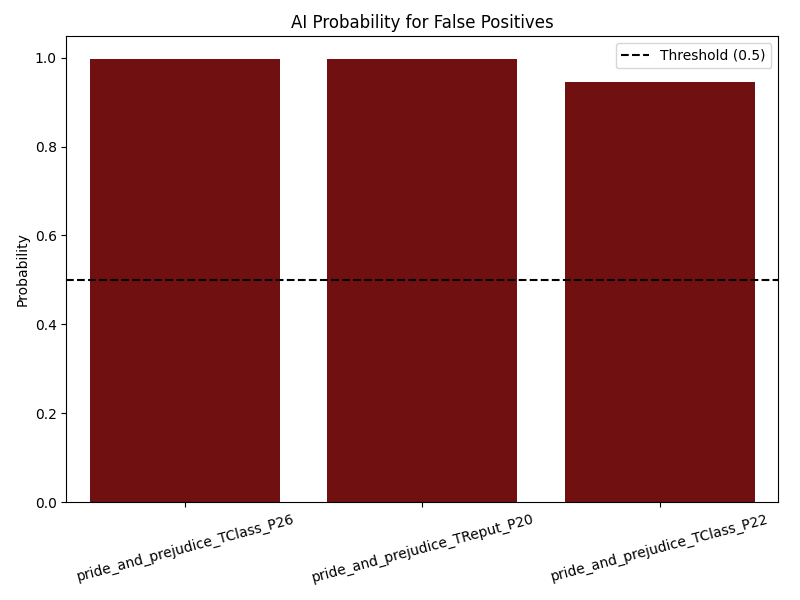

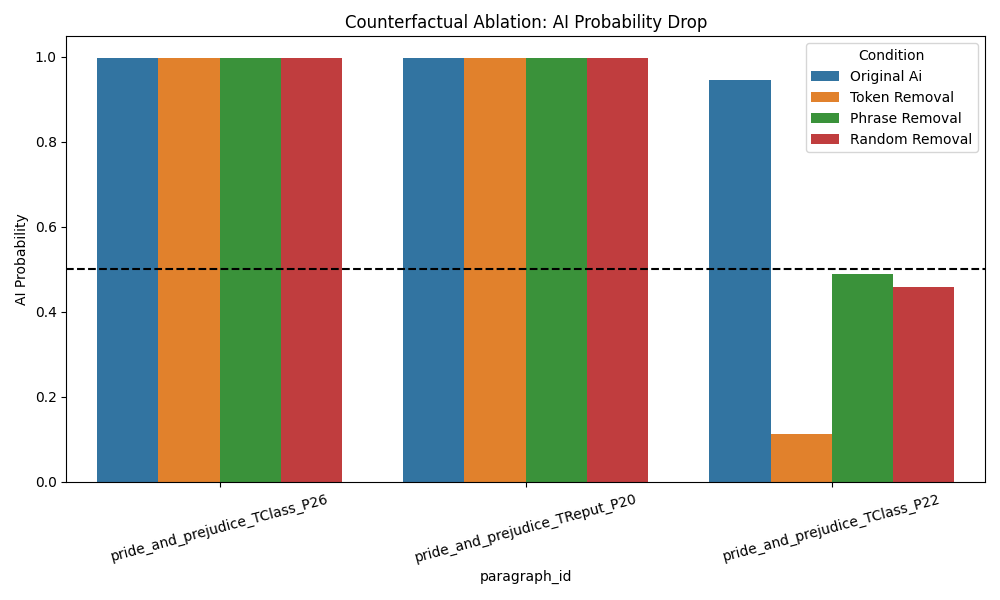

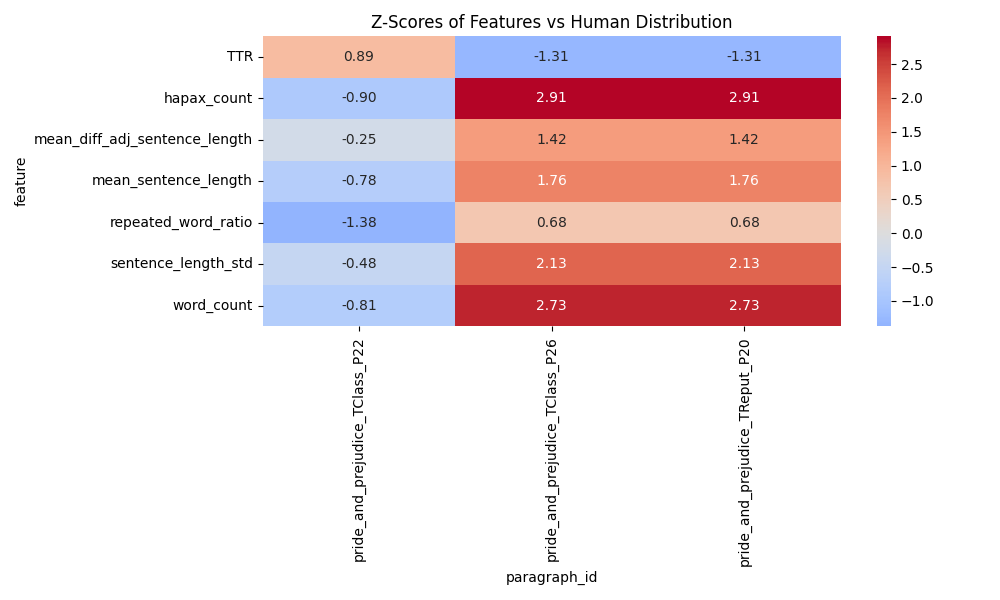

In [4]:

display(Image(filename='../results/error_analysis/plots/fp_ai_probabilities.png'))
display(Image(filename='../results/error_analysis/plots/counterfactuals.png'))
display(Image(filename='../results/error_analysis/plots/z_scores_heatmap.png'))


## Final Research Conclusion

In [5]:

for idx, row in summary_df.iterrows():
    print(f"\nFALSE POSITIVE {idx+1}: {row['paragraph_id']}")
    print(f"Prediction:\nAI probability = {row['ai_probability']:.4f}")
    print(f"Likely explanation:\n{row['main_error_hypothesis']}")
    print(f"Supporting evidence:\n- Strongest anomaly: {row['strongest_statistical_anomaly']}")
    print(f"- Strongest AI attribution: {row['strongest_ai_attribution']}")
    print(f"- Counterfactual effect: {row['counterfactual_effect']}")
    print(f"- AI-isms present: {row['ai_isms_present']}")
    print("-" * 50)



FALSE POSITIVE 1: pride_and_prejudice_TClass_P26
Prediction:
AI probability = 0.9982
Likely explanation:
AI-like sentence rhythm
Supporting evidence:
- Strongest anomaly: hapax_count (Z=2.91)
- Strongest AI attribution: ourn
- Counterfactual effect: Token Drop: 0.00, Phrase Drop: -0.00
- AI-isms present: nan
--------------------------------------------------

FALSE POSITIVE 2: pride_and_prejudice_TReput_P20
Prediction:
AI probability = 0.9982
Likely explanation:
AI-like sentence rhythm
Supporting evidence:
- Strongest anomaly: hapax_count (Z=2.91)
- Strongest AI attribution: ourn
- Counterfactual effect: Token Drop: 0.00, Phrase Drop: -0.00
- AI-isms present: nan
--------------------------------------------------

FALSE POSITIVE 3: pride_and_prejudice_TClass_P22
Prediction:
AI probability = 0.9456
Likely explanation:
Strong stylistic regularity (phrase dependence)
Supporting evidence:
- Strongest anomaly: repeated_word_ratio (Z=-1.38)
- Strongest AI attribution: ľ
- Counterfactual eff